This script is for validating two models
1. The implementation of the thickened flame model. 
    
    This is done by using the method:<br>
    flame_simulation.flame.set_stretched_thickened_flame(Fth,Fsp,Fr).<br>
    
    For the ATF model, Fth=Fsp=Fr. It is expected that the laminar flame speed will stay the same, 
    and the flame thickness is multplied by the thickening factor.<br>
    <br>
    
2. Simplified Transport Model

    The S-TF model is used to model the stretched response of the flame when a constant lewis number Le is provided.
    Thus, implementation of a constant lewis number assumption and a constant Prandtl number assumption is 
    implemented and is accessed via the gas object:<br>
    
    flame_simulation.flame.transport_model='simplified' <br>
    gas.set_lewis_number(Le)<br>
    gas.set_prandtl_number(Pr)<br>
    

In [25]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt


In [26]:
mech = "BFER_methane.yaml"
gas = ct.Solution(mech)
Tu = 300 #K
Pu = ct.one_atm
gas.TP = Tu, Pu
phi = 0.7
width=0.16
fuel = 'CH4:1.0'
air = 'O2:1.0, N2:3.76'
Le = 1.0
Pr = 0.7

In [27]:
def thermal_flame_thickness(flame):
    """
    Compute thermal flame thickness using:
        δ_T = (T_max - T_min) / max(dT/dx)
    """
    dTdx = np.gradient(flame.T, flame.grid)
    Tmax = flame.T.max()
    Tmin = flame.T.min()
    return 100*(Tmax - Tmin) / dTdx.max()


In [28]:
def compute_sl(flame):
    return flame.velocity[0]

In [29]:
F = [1.0, 2.0, 5.0, 10.0]
colours = ['red', 'green', 'blue', 'orange']
flame_list = []
df_list = []

In [30]:
for i in range(0,len(F)):
    gas = ct.Solution(mech)
    gas.set_equivalence_ratio(phi, fuel, air)
    freeflame = ct.FreeFlame(gas,width=width)
    freeflame.flame.set_stretched_thickened_flame(F[i],F[i],F[i]) # Set Fsp, Fth and Fr =1
    freeflame.flame.transport_model='mixture-averaged'
    freeflame.set_refine_criteria(ratio=3, slope=0.05, curve=0.1)
    freeflame.solve(loglevel=0, auto=False)
    flame_list.append(freeflame)
    df_list.append(thermal_flame_thickness(freeflame))

Text(0.5, 1.0, 'Flame thickness vs Thickening Factor, F')

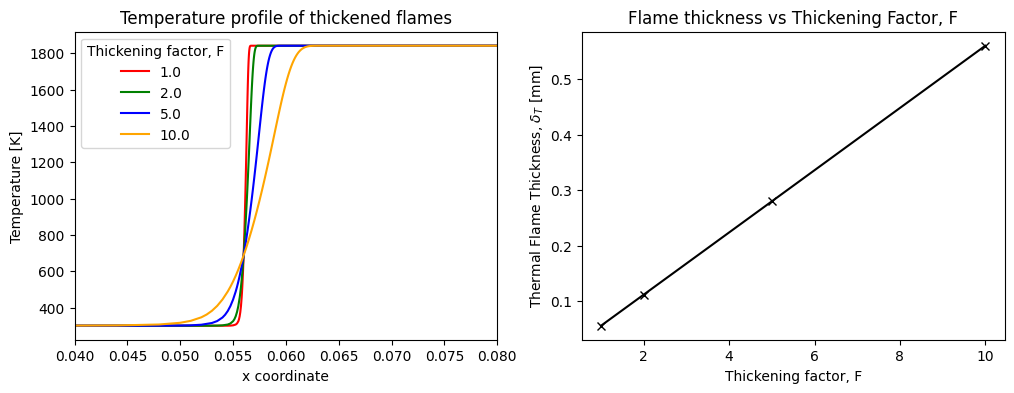

In [31]:
## Plot temperature profiles and flame thickness of each flame.
fig, ax = plt.subplots(1, 2, figsize=(12, 4))  # wider figure
for i in range(0,len(F)):
    ax[0].plot(flame_list[i].grid, flame_list[i].T,color=colours[i])
    ax[0].set_xlim(0.04,0.08)
    ax[0].set_xlabel('x coordinate')
    ax[0].set_ylabel('Temperature [K]')
    ax[0].legend(F,title="Thickening factor, F")
    ax[0].set_title('Temperature profile of thickened flames')
    
ax[1].plot(F, df_list, 'k-x')
ax[1].set_xlabel('Thickening factor, F')
ax[1].set_ylabel(r'Thermal Flame Thickness, $\delta_T$ [mm]')
ax[1].set_title('Flame thickness vs Thickening Factor, F')

In [32]:
# Verify laminar flame speed is constant
for i in range(0,len(F)):
    print(f"Laminar flame speed at F={F[i]} is {compute_sl(flame_list[i])}")

Laminar flame speed at F=1.0 is 0.2054346555988323
Laminar flame speed at F=2.0 is 0.20543465422171922
Laminar flame speed at F=5.0 is 0.2048843780133521
Laminar flame speed at F=10.0 is 0.2049378363280594


In [33]:
# Verify laminar flame speed is constant
for i in range(0,len(F)):
    print(f"Laminar flame thickness at F={F[i]} is {df_list[i]}")

Laminar flame thickness at F=1.0 is 0.05596290294914486
Laminar flame thickness at F=2.0 is 0.11192580993977096
Laminar flame thickness at F=5.0 is 0.27988481695854395
Laminar flame thickness at F=10.0 is 0.5601077670224757


In [34]:
# Create a flame with simplified transport model to compare with the mixture averaged transport model
simplified_flame_list = []
simplified_df_list = []

In [35]:
for i in range(0,len(F)):
    gas = ct.Solution(mech)
    gas.set_equivalence_ratio(phi, fuel, air)
    simpflame = ct.FreeFlame(gas,width=width)
    simpflame.flame.set_stretched_thickened_flame(F[i],F[i],F[i]) # Set Fsp, Fth and Fr =1
    simpflame.flame.transport_model='simplified'
    # Const Le
    gas.set_lewis_number(Le)
    # Const Pr
    gas.set_prandtl_number(Pr)
    simpflame.set_refine_criteria(ratio=3, slope=0.05, curve=0.1)
    simpflame.solve(loglevel=0, auto=False)
    simplified_flame_list.append(simpflame)
    simplified_df_list.append(thermal_flame_thickness(simpflame))

Text(0.5, 1.0, 'Mixture Averaged Flame Thickness (black -) vs Simplified (blue --)')

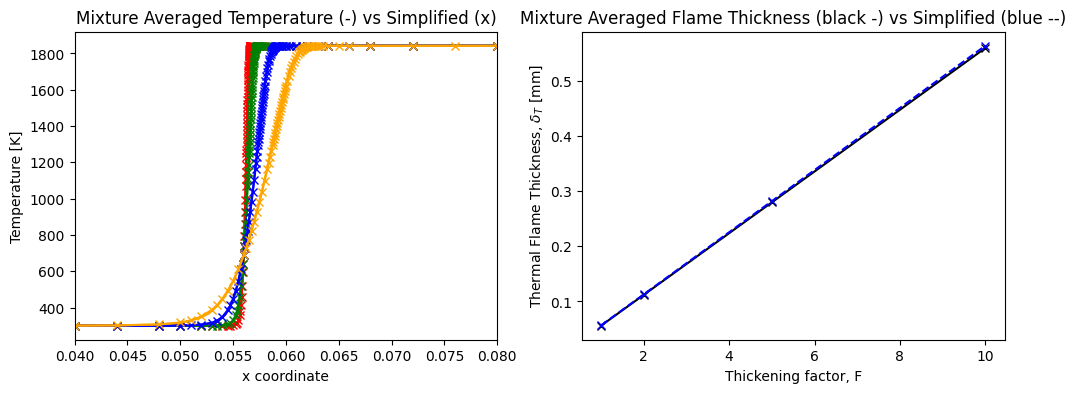

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))  # wider figure
for i in range(0,len(F)):
    ax[0].plot(flame_list[i].grid, flame_list[i].T,color=colours[i])
    ax[0].plot(simplified_flame_list[i].grid, simplified_flame_list[i].T,color=colours[i],marker='x')
    ax[0].set_xlim(0.04,0.08)
    ax[0].set_xlabel('x coordinate')
    ax[0].set_ylabel('Temperature [K]')
    ax[0].set_title('Mixture Averaged Temperature (-) vs Simplified (x)')
    
ax[1].plot(F, df_list, 'k-x')
ax[1].plot(F, simplified_df_list, 'b--x')
ax[1].set_xlabel('Thickening factor, F')
ax[1].set_ylabel(r'Thermal Flame Thickness, $\delta_T$ [mm]')
ax[1].set_title('Mixture Averaged Flame Thickness (black -) vs Simplified (blue --)')


In [37]:
# Verify laminar flame speed is constant
for i in range(0,len(F)):
    print(f"Laminar flame speed at F={F[i]} is {compute_sl(simplified_flame_list[i])}")

Laminar flame speed at F=1.0 is 0.20892473446877802
Laminar flame speed at F=2.0 is 0.20893058297623707
Laminar flame speed at F=5.0 is 0.20842496300636984
Laminar flame speed at F=10.0 is 0.2085948995282557


In [38]:
# Verify laminar flame speed is constant
for i in range(0,len(F)):
    print(f"Laminar flame thickness at F={F[i]} is {simplified_df_list[i]}")

Laminar flame thickness at F=1.0 is 0.056431348503685544
Laminar flame thickness at F=2.0 is 0.11286707699022062
Laminar flame thickness at F=5.0 is 0.2820559349402296
Laminar flame thickness at F=10.0 is 0.564288319850148
